# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [2]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [3]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/birds/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [4]:
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_group']
))

# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)


In [5]:
combined_df = combined_df[combined_df['migration_group']=='diurnal']

In [6]:
combined_df

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
830741,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,Andorra - El Tarter,L6125826,P,42.581210,1.650503,2017-08-26,obsr233336,S38826099,Traveling,diurnal
830742,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,El Pas de la Casa,L5043409,H,42.543469,1.733136,2021-09-17,obsr1056188,S94813143,Traveling,diurnal
830743,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,val d'Incles,L18827021,P,42.607980,1.687589,2022-05-02,obsr1529396,S108821912,Traveling,diurnal
830744,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,Valle de Incles,L26374511,P,42.601557,1.697731,2022-06-20,obsr1641334,S146364201,Incidental,diurnal
830745,European Honey-buzzard,Pernis apivorus,3.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,"Auto selected 42.60736, 1.71605",L21151068,P,42.607364,1.716046,2022-08-28,obsr359284,S120190920,Traveling,diurnal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876401,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,4Ð Ð²ÑÐ»Ð¸ÑÑ ÐÑÐ²Ð´ÐµÐ½Ð½Ð¾ÐºÑÐ»ÑÑÐµÐ...,L11936119,P,48.250136,25.948428,2020-07-18,obsr1524677,S71750798,Traveling,diurnal
876402,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,Ð²ÑÐ»Ð¸ÑÑ ÐÐ¾ÑÐºÐ¾Ð²ÑÑÐºÐ¾Ñ ÐÐ»ÑÐ¼Ð¿...,L11895530,P,48.290152,25.997833,2020-07-14,obsr1524677,S71493671,Traveling,diurnal
876403,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, ÐÐ¾ÑÑÑÐ½Ñ Ð¨ÐµÑÑÐ²ÑÑ, Ð...",L14419836,P,48.408663,25.952795,2021-08-03,obsr1524677,S92697785,Traveling,diurnal
876404,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð§Ð°Ð³Ð¾Ñ, Ð§ÐµÑÐ½ÑÐ²ÐµÑÑÐº...",L16080784,P,48.251779,26.012127,2021-08-12,obsr1524677,S93111782,Traveling,diurnal


In [7]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
830741,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,Andorra - El Tarter,L6125826,P,42.581210,1.650503,2017-08-26,obsr233336,S38826099,Traveling,diurnal
830742,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,El Pas de la Casa,L5043409,H,42.543469,1.733136,2021-09-17,obsr1056188,S94813143,Traveling,diurnal
830743,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,val d'Incles,L18827021,P,42.607980,1.687589,2022-05-02,obsr1529396,S108821912,Traveling,diurnal
830744,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,Valle de Incles,L26374511,P,42.601557,1.697731,2022-06-20,obsr1641334,S146364201,Incidental,diurnal
830745,European Honey-buzzard,Pernis apivorus,3.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,"Auto selected 42.60736, 1.71605",L21151068,P,42.607364,1.716046,2022-08-28,obsr359284,S120190920,Traveling,diurnal


In [8]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-08 00:00:00 to 2022-11-20 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022]


In [9]:
combined_df = combined_df[combined_df['year'] < 2023]

## 3. Basic Statistics

In [10]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 45,665
Number of countries: 42
Number of states/regions: 545
Number of counties: 774
Number of unique species: 1
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 6703

Observations with count data: 45,665 (100.0%)
Total birds counted: 783,327
Average count per observation: 17.15
Median count: 1
Maximum count in single observation: 8,000
Minimum count: 1


### outlier removal for col 'howMany'

In [11]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0

Total outliers: 6,959 (15.24% of data)

Outlier summary:
count    6959.000000
mean      103.474925
std       352.380215
min         7.000000
25%        11.000000
50%        20.000000
75%        55.000000
max      8000.000000
Name: howMany, dtype: float64


In [12]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
7.0     541
8.0     478
10.0    360
9.0     341
12.0    281
11.0    239
15.0    228
20.0    199
14.0    187
13.0    162
30.0    156
17.0    154
16.0    141
50.0    133
18.0    126
25.0    119
40.0     93
19.0     90
35.0     89
21.0     79
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-2-50        5153
51-100        670
101-500       868
501-1000      134
1001-5000     130
5000+           4
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    7
  Max outlier value:    8,000
  Mean outlier value:   103.47
  Median outlier value: 20


In [13]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 1,136

Locality Type Distribution:
LOCALITY TYPE
H    941
P    195
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    82.83%
P    17.17%
Name: proportion, dtype: object


#### dropping outliers

In [14]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 45,665
Rows after:  44,529
Rows dropped: 1,136 (2.49% of data)


## 4. Analysis by Country

In [15]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 18164


In [16]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain               19231               1             18               41             130865.0
          PT               Portugal                4159               1             18              202               9201.0
          FR                 France                4134               1             13               96              14062.0
          SE                 Sweden                2007               1             21                0               9898.0
          IT                  Italy                1582               1             20                0               6141.0
          DE                Germany                1572               1             16              270               2514.0
          BG               Bulgaria                1349               1             28                

In [17]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain               19231               1             18               41             130865.0              2486
          FR                 France                4134               1             13               96              14062.0               873
          DE                Germany                1572               1             16              270               2514.0               505
          PT               Portugal                4159               1             18              202               9201.0               500
          IT                  Italy                1582               1             20                0               6141.0               406
          SE                 Sweden                2007               1             21                0               9

### relative to number of observers

In [18]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          PT               Portugal                4159               1             18              202               9201.0               500               8.3
          ES                  Spain               19231               1             18               41             130865.0              2486               7.7
          LT              Lithuania                 237               1             10                0                332.0                31               7.6
          MD                Moldova                  78               1             23                0                221.0                13               6.0
          FI                Finland                 940               1             19                0               2058.0               15

### year and locality type

In [19]:
yearly_obs = combined_df.groupby('year').size().sort_index()

print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")
        locality_counts = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')
            .size()
            .sort_values(ascending=False)
        )
        for locality, loc_count in locality_counts.items():
            print(f"    {locality}: {loc_count:,}")

        h = locality_counts.get('H', 0)
        p = locality_counts.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{diff:,}")


Observations by Year:
  2017: 4,583
    H: 3,064
    P: 1,519
    H - P = +1,545
  2018: 5,928
    H: 3,739
    P: 2,189
    H - P = +1,550
  2019: 7,220
    H: 4,738
    P: 2,482
    H - P = +2,256
  2020: 7,772
    H: 4,641
    P: 3,131
    H - P = +1,510
  2021: 8,596
    H: 5,132
    P: 3,464
    H - P = +1,668
  2022: 10,430
    H: 6,325
    P: 4,105
    H - P = +2,220


## 5. Species Analysis

In [20]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name Scientific Name  Total Observations  Countries Found  States Found  Total Count
European Honey-buzzard Pernis apivorus               44529               42           545     208528.0


## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 4,583
  2018: 5,928
  2019: 7,220
  2020: 7,772
  2021: 8,596
  2022: 10,430

Observations by month of 2017
  January: 2
  March: 11
  April: 89
  May: 860
  June: 415
  July: 489
  August: 1,470
  September: 1,034
  October: 210
  November: 2
  December: 1
  → Peak migration month: August (1,470 observations)

Observations by month of 2018
  March: 4
  April: 196
  May: 1,511
  June: 471
  July: 639
  August: 1,365
  September: 1,567
  October: 170
  November: 5
  → Peak migration month: September (1,567 observations)

Observations by month of 2019
  March: 9
  April: 204
  May: 1,425
  June: 698
  July: 829
  August: 2,075
  September: 1,779
  October: 196
  November: 5
  → Peak migration month: August (2,075 observations)

Observations by month of 2020
  March: 11
  April: 178
  May: 1,803
  June: 1,009
  July: 1,098
  August: 1,773
  September: 1,700
  October: 197
  November: 3
  → Peak migration month: May (1,803 observations)

Ob

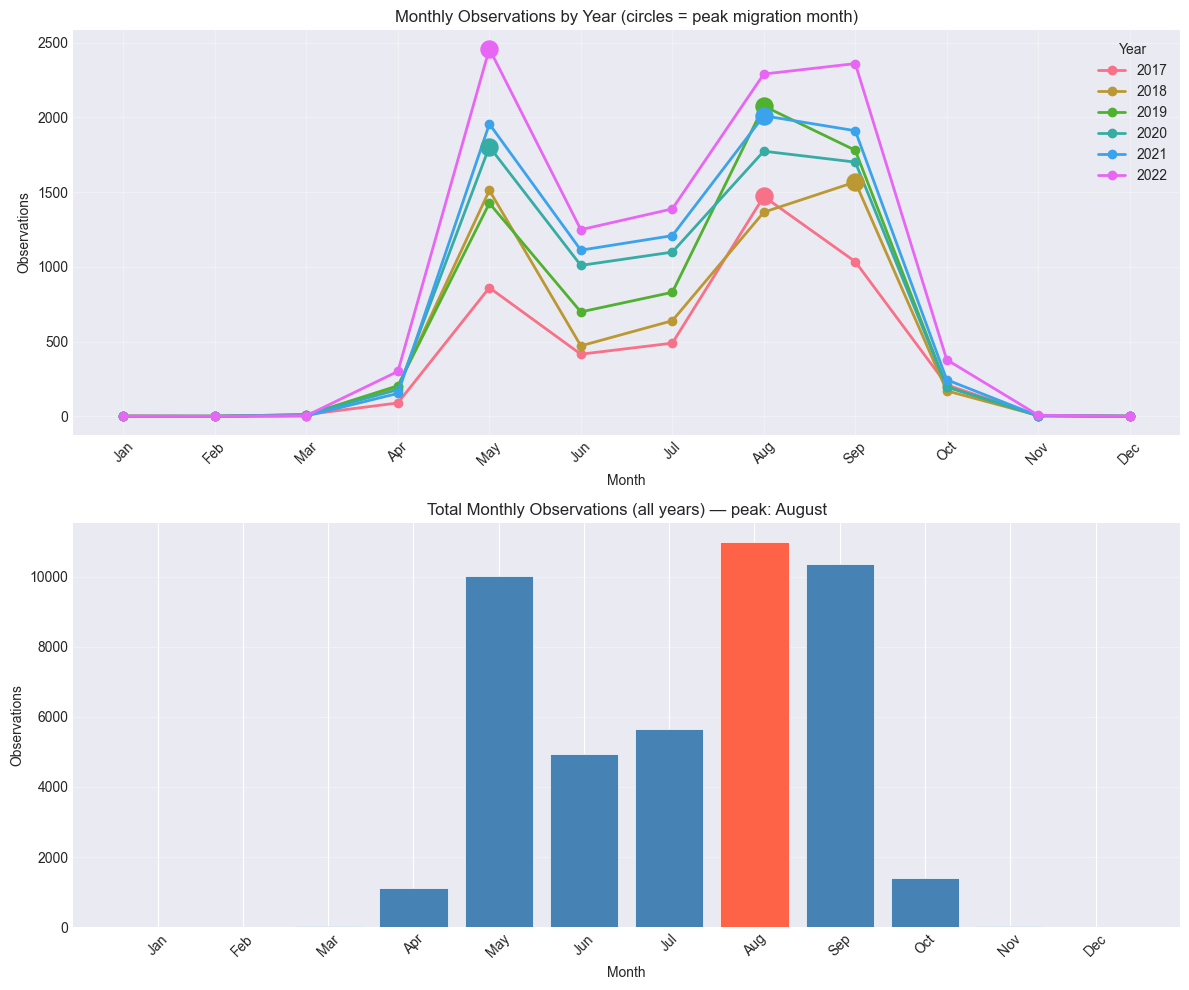

In [21]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [22]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 4,583.0 observations | 22,045.0 number of birds counted
  2018: 5,928.0 observations | 33,187.0 number of birds counted
  2019: 7,220.0 observations | 37,318.0 number of birds counted
  2020: 7,772.0 observations | 34,160.0 number of birds counted
  2021: 8,596.0 observations | 37,050.0 number of birds counted
  2022: 10,430.0 observations | 44,768.0 number of birds counted


In [23]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 17.33
    Avg obs per observer: 3.60
    Avg bird per observer: 21.02
    Avg obs per observer: 3.75
    Avg bird per observer: 19.31
    Avg obs per observer: 3.74
    Avg bird per observer: 16.21
    Avg obs per observer: 3.69
    Avg bird per observer: 14.21
    Avg obs per observer: 3.30
    Avg bird per observer: 13.07
    Avg obs per observer: 3.05


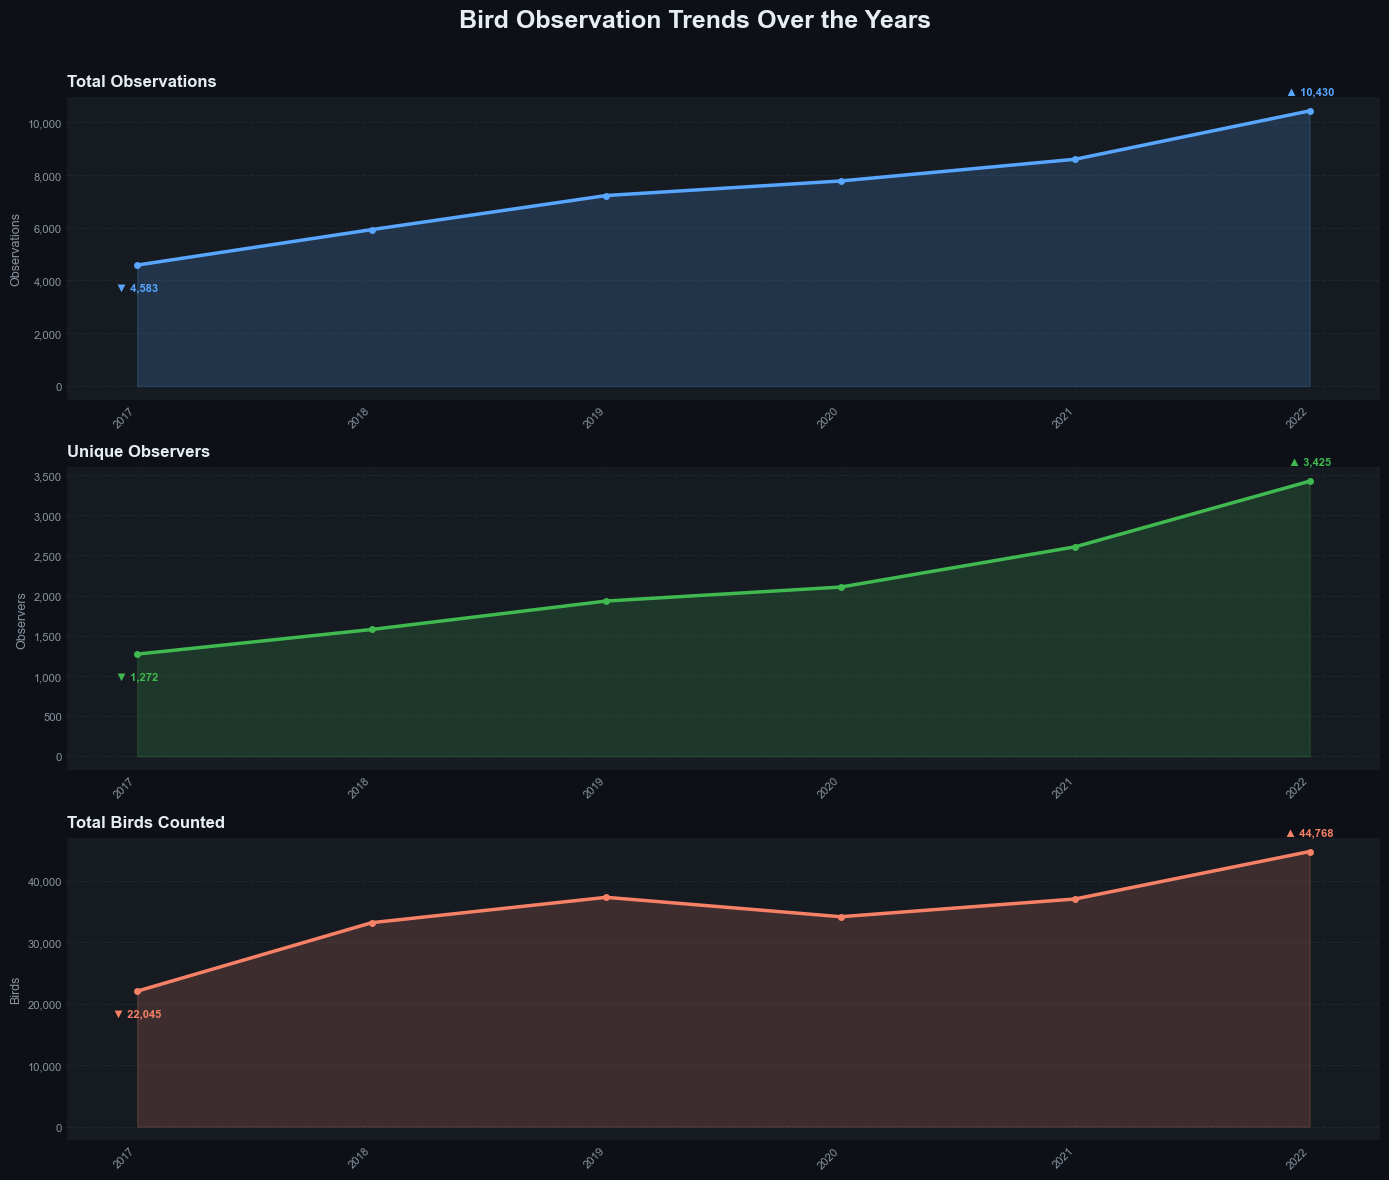

Plot saved to yearly_trends.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### 8.3 Migration Pattern Analysis by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [25]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Autumn Migration (Late Aug to Early Dec): 17,335 observations
  Spring Migration (Mid-Mar to Mid-Jun): 13,944 observations
  Summer (Jul to Early Aug): 11,066 observations
  Winter (Late Dec to Early Mar): 2,184 observations


## 7. Distance to cities

In [26]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [27]:
df_migratory = combined_df

In [28]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group,obsDt,year,month,day_of_week,day_of_year,howMany,season,closest_city,closest_city_country,distance_km
830741,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,Andorra - El Tarter,L6125826,P,42.581210,1.650503,2017-08-26,obsr233336,S38826099,Traveling,diurnal,2017-08-26,2017,8,5,238,1.0,Autumn Migration (Late Aug to Early Dec),Andorra,Andorra,15.85
830742,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,El Pas de la Casa,L5043409,H,42.543469,1.733136,2021-09-17,obsr1056188,S94813143,Traveling,diurnal,2021-09-17,2021,9,4,260,1.0,Autumn Migration (Late Aug to Early Dec),Andorra,Andorra,23.25
830743,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,val d'Incles,L18827021,P,42.607980,1.687589,2022-05-02,obsr1529396,S108821912,Traveling,diurnal,2022-05-02,2022,5,0,122,1.0,Spring Migration (Mid-Mar to Mid-Jun),Andorra,Andorra,20.91
830744,European Honey-buzzard,Pernis apivorus,1.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,Valle de Incles,L26374511,P,42.601557,1.697731,2022-06-20,obsr1641334,S146364201,Incidental,diurnal,2022-06-20,2022,6,0,171,1.0,Winter (Late Dec to Early Mar),Andorra,Andorra,21.54
830745,European Honey-buzzard,Pernis apivorus,3.0,NaN,Andorra,AD,Canillo,AD-02,NaN,NaN,NaN,"Auto selected 42.60736, 1.71605",L21151068,P,42.607364,1.716046,2022-08-28,obsr359284,S120190920,Traveling,diurnal,2022-08-28,2022,8,6,240,3.0,Autumn Migration (Late Aug to Early Dec),Andorra,Andorra,23.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876401,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,4Ð Ð²ÑÐ»Ð¸ÑÑ ÐÑÐ²Ð´ÐµÐ½Ð½Ð¾ÐºÑÐ»ÑÑÐµÐ...,L11936119,P,48.250136,25.948428,2020-07-18,obsr1524677,S71750798,Traveling,diurnal,2020-07-18,2020,7,5,200,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,6.82
876402,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,Ð²ÑÐ»Ð¸ÑÑ ÐÐ¾ÑÐºÐ¾Ð²ÑÑÐºÐ¾Ñ ÐÐ»ÑÐ¼Ð¿...,L11895530,P,48.290152,25.997833,2020-07-14,obsr1524677,S71493671,Traveling,diurnal,2020-07-14,2020,7,1,196,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,8.65
876403,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, ÐÐ¾ÑÑÑÐ½Ñ Ð¨ÐµÑÑÐ²ÑÑ, Ð...",L14419836,P,48.408663,25.952795,2021-08-03,obsr1524677,S92697785,Traveling,diurnal,2021-08-03,2021,8,1,215,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,12.01
876404,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð§Ð°Ð³Ð¾Ñ, Ð§ÐµÑÐ½ÑÐ²ÐµÑÑÐº...",L16080784,P,48.251779,26.012127,2021-08-12,obsr1524677,S93111782,Traveling,diurnal,2021-08-12,2021,8,3,224,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,11.70


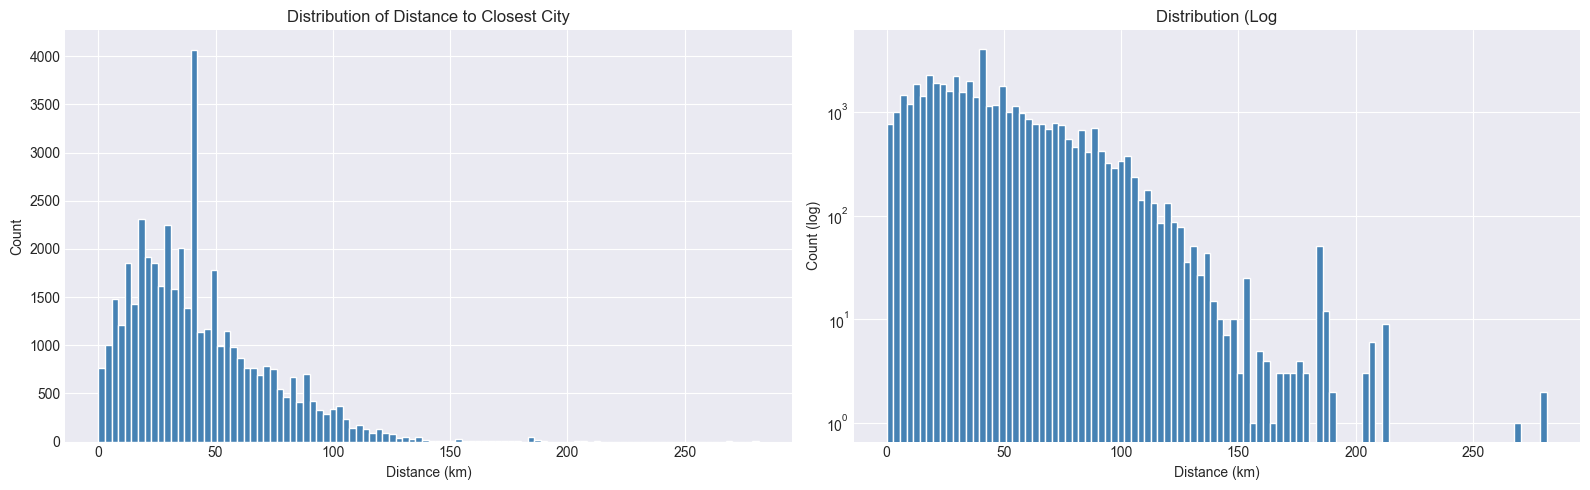

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

### Distance Aggregations

The following cells calculate the average distance to the closest city across three groupings:
1. **Per year** — how the average distance changes over time
2. **Per species** — average across all years for each species
3. **Per species per year** — the most granular breakdown

In [30]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         42.514370              39.970            4583
 2018         43.556253              39.970            5928
 2019         42.682589              39.970            7220
 2020         42.077568              35.825            7772
 2021         43.033510              36.550            8596
 2022         42.524878              36.140           10430


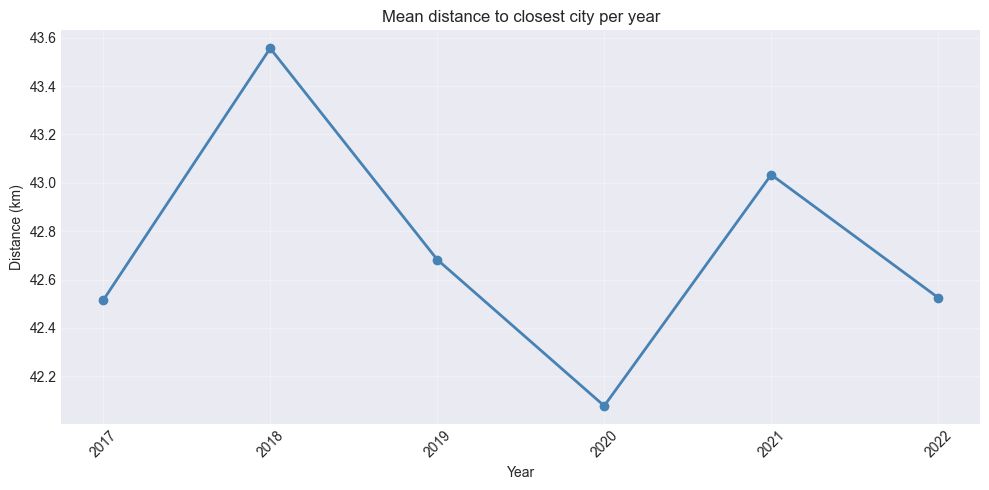

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dist_by_year['year'], dist_by_year['mean_distance_km'],
        color='steelblue', marker='o', linewidth=2, markersize=6)

ax.set_xticks(dist_by_year['year'])
ax.set_xticklabels(dist_by_year['year'], rotation=45)
ax.set_title('Mean distance to closest city per year')
ax.set_xlabel('Year')
ax.set_ylabel('Distance (km)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.tight_layout()
plt.show()

In [32]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
           COMMON NAME  mean_distance_km  median_distance_km  n_observations
European Honey-buzzard         42.706787               38.84           44529


In [33]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
           COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
European Honey-buzzard  2017         42.514370              39.970            4583
European Honey-buzzard  2018         43.556253              39.970            5928
European Honey-buzzard  2019         42.682589              39.970            7220
European Honey-buzzard  2020         42.077568              35.825            7772
European Honey-buzzard  2021         43.033510              36.550            8596
European Honey-buzzard  2022         42.524878              36.140           10430

Pivot table — mean distance (km) by species × year:
year                     2017   2018   2019   2020   2021   2022
COMMON NAME                                                     
European Honey-buzzard  42.51  43.56  42.68  42.08  43.03  42.52


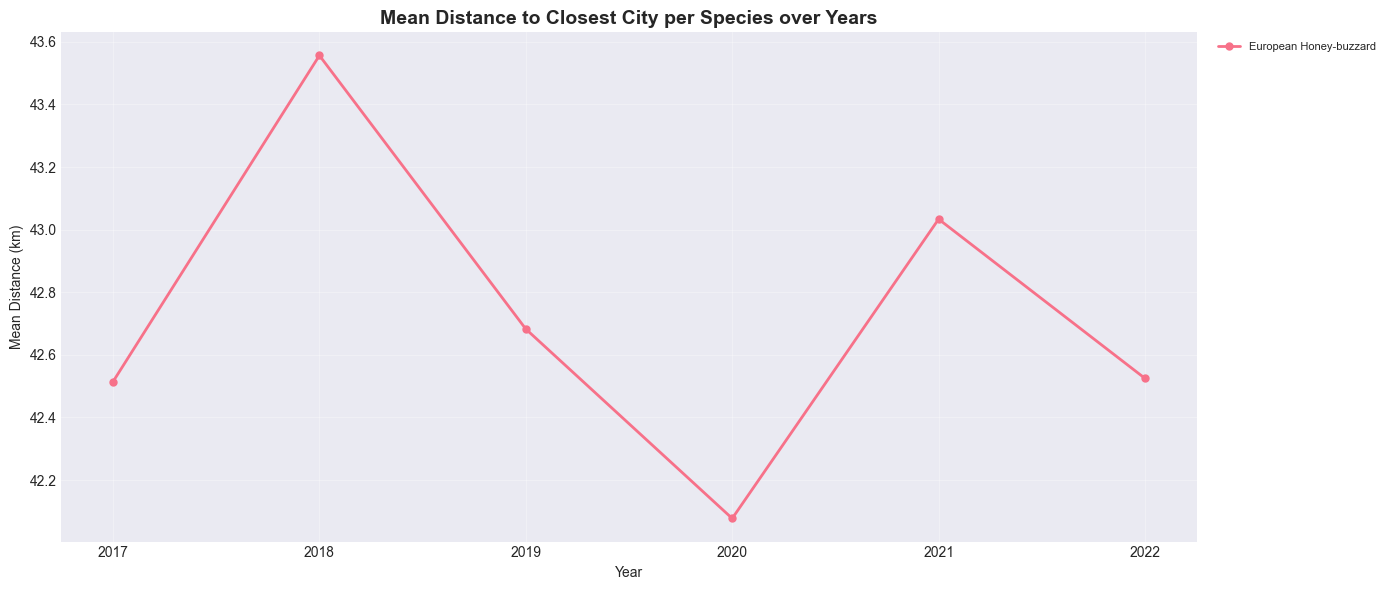

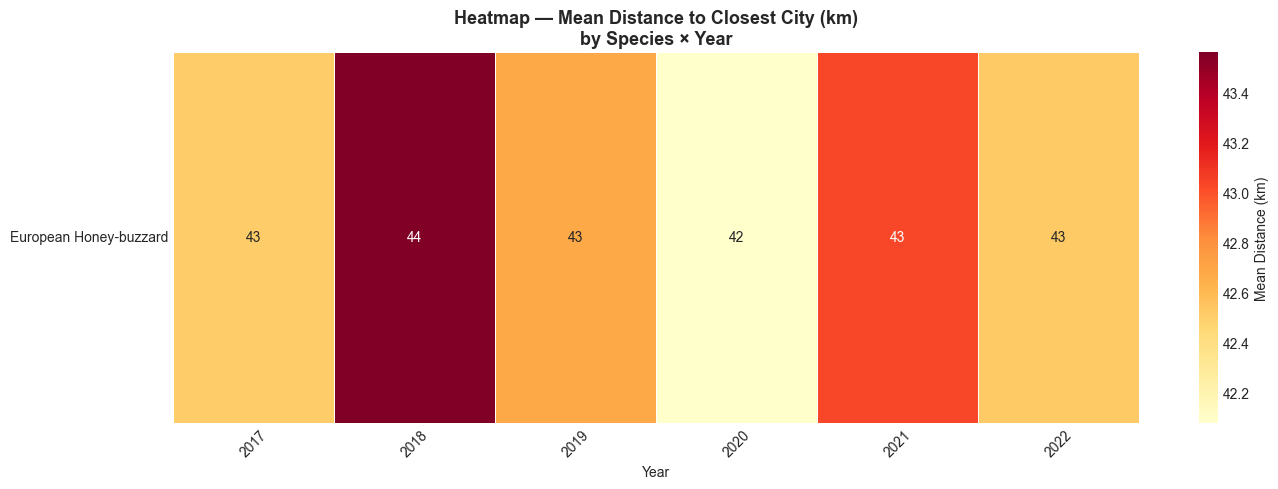

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ──────────────────────────────────────────────────────────
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


In [35]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    44529.000000
mean        42.706787
std         28.366533
min          0.100000
25%         21.380000
50%         38.840000
75%         57.650000
max        281.480000
Name: distance_km, dtype: float64

Median:  38.84 km
Skewness: 1.11
% within 10km:  8.8%
% within 50km:  68.5%
% within 100km: 95.7%
